# Warmup time

In this example we use the [pyALF](https://github.com/ALF-QMC/pyALF) interface to run ALF on a $4\times 4$ Hubbard square lattice, with the Mz choice of Hubbard-Stratonovich transformation, at $U/t=4$, half-band filling, and inverse temperature $\beta t = 5$.

A Monte Carlo simulation starts from an initial (typically random) auxiliary-field configuration, which is generally far from equilibrium. The first bins therefore do not sample the equilibrium distribution and must be discarded before performing the analysis; the number of bins discarded is denoted `N_skip`.

Below we go through the steps of running a simulation, visualizing the equilibration (warmup) transient in the raw bins of the energy, and quantitatively estimating a safe value of `N_skip` by tracking how the jackknife estimate of the energy changes as `N_skip` is increased. This mirrors the approach used to estimate the autocorrelation time, but scans `N_skip` instead of `N_rebin`.

---

**1.** Import `Simulation` class from the `py_alf` python module, which provides the interface with ALF, as well as mathematics and plotting packages:

In [1]:
from py_alf import Simulation, ALF_source  # Interface with ALF
#
import numpy as np                        # Numerical library
import matplotlib.pyplot as plt           # Plotting library
alf_src = ALF_source(branch='master')     # Obtain ALF source code


Checking out branch master
Your branch is up to date with 'origin/master'.


Already on 'master'


**2.** Create an instance of `Simulation`, specifying the necessary parameters. Here we use a moderate `NSweep` so that bins are close to statistically independent, keeping the focus on the initial equilibration transient rather than on bin-to-bin autocorrelation:

In [9]:
sim = Simulation(
    alf_src,
    'Hubbard',                    # Hamiltonian
    {                             # Model and simulation parameters
        'Lattice_type': 'Square', #    Lattice type
        'L1': 4,                  #    Lattice length in the first unit vector direction
        'L2': 4,                  #    Lattice length in the second unit vector direction
        'Checkerboard': False,    #    Whether checkerboard decomposition is used or not
        'Symm': True,             #    Whether symmetrization takes place
        'ham_T': 1.0,             #    Hopping parameter
        'ham_U': 4.0,             #    Hubbard interaction
        'beta': 5.0,              #    Inverse temperature
        'Dtau': 0.1,              #    Trotter time step, Ltrot=beta/Dtau
        'Mz': True,               #    If true, sets the M_z-Hubbard model: Nf=2, N_sum=1,
                                  #             HS field couples to z-component of magnetization
        'NSweep': 5,              #    Number of sweeps per bin
        'NBin': 500,              #    Number of bins
    },
)


**3.** Compile ALF, downloading it first if not found locally. This may take a few minutes:

In [10]:
sim.compile()                            # Compilation needs to be performed only once

Checking out branch master
Your branch is up to date with 'origin/master'.


Already on 'master'


Compiling ALF... 
Cleaning up Prog/
Cleaning up Libraries/
Cleaning up Analysis/
Compiling Libraries


entanglement_mod.F90:35:2:

   35 | #warning "You are compiling entanglement without MPI. No Renyi entropy results possible, all other observables still work!"
      |  1~~~~~~
ar: creating archive modules_90.a
ar: creating archive libqrref.a


Compiling Analysis
Compiling Program
Compiling program modules
Parsing Hamiltonian parameters
filenames: Hamiltonians/Hamiltonian_Kondo_smod.F90 Hamiltonians/Hamiltonian_Kondo_read_write_parameters.F90
filenames: Hamiltonians/Hamiltonian_Hubbard_smod.F90 Hamiltonians/Hamiltonian_Hubbard_read_write_parameters.F90
filenames: Hamiltonians/Hamiltonian_Hubbard_Plain_Vanilla_smod.F90 Hamiltonians/Hamiltonian_Hubbard_Plain_Vanilla_read_write_parameters.F90
filenames: Hamiltonians/Hamiltonian_tV_smod.F90 Hamiltonians/Hamiltonian_tV_read_write_parameters.F90
filenames: Hamiltonians/Hamiltonian_LRC_smod.F90 Hamiltonians/Hamiltonian_LRC_read_write_parameters.F90
filenames: Hamiltonians/Hamiltonian_Z2_Matter_smod.F90 Hamiltonians/Hamiltonian_Z2_Matter_read_write_parameters.F90
filenames: Hamiltonians/Hamiltonian_Spin_Peierls_smod.F90 Hamiltonians/Hamiltonian_Spin_Peierls_read_write_parameters.F90
Link program
Done.


**4.** Perform the simulation and the default analysis:

In [11]:
sim.run()                                # Perform the actual simulation in ALF
sim.analysis()                           # Perform default (N_skip=0) analysis
obs = sim.get_obs()
obs.iloc[0][['Ener_scal0', 'Ener_scal0_err']]


Prepare directory "/Users/fassaad/Programs/ALF/ALF_Tutorial/jupyterbook/source/05-caveats/ALF_data/Hubbard_Square_L1=4_L2=4_Checkerboard=False_Symm=True_T=1.0_U=4.0_beta=5.0_Dtau=0.1_Mz=True" for Monte Carlo run.
Create new directory.
Run /Users/fassaad/Programs/ALF/ALF/Prog/ALF.out
 ALF Copyright (C) 2016 - 2022 The ALF project contributors
 This Program comes with ABSOLUTELY NO WARRANTY; for details see license.GPL
 This is free software, and you are welcome to redistribute it under certain conditions.
 No initial configuration


 Setting N_FL = 2 since this is mandatory for Mz-Hubbard model


### Analyzing /Users/fassaad/Programs/ALF/ALF_Tutorial/jupyterbook/source/05-caveats/ALF_data/Hubbard_Square_L1=4_L2=4_Checkerboard=False_Symm=True_T=1.0_U=4.0_beta=5.0_Dtau=0.1_Mz=True ###
/Users/fassaad/Programs/ALF/ALF_Tutorial/jupyterbook/source/05-caveats
Scalar observables:
Ener_scal
Kin_scal
Part_scal
Pot_scal
Histogram observables:
Equal time observables:
Den_eq
Green_eq
SpinT_eq
SpinXY_eq
SpinZ_eq
Time displaced observables:
Den_tau
Green_tau
SpinT_tau
SpinXY_tau
SpinZ_tau
/Users/fassaad/Programs/ALF/ALF_Tutorial/jupyterbook/source/05-caveats/ALF_data/Hubbard_Square_L1=4_L2=4_Checkerboard=False_Symm=True_T=1.0_U=4.0_beta=5.0_Dtau=0.1_Mz=True
No orbital locations saved.


Ener_scal0       -13.221045
Ener_scal0_err     0.020506
Name: /Users/fassaad/Programs/ALF/ALF_Tutorial/jupyterbook/source/05-caveats/ALF_data/Hubbard_Square_L1=4_L2=4_Checkerboard=False_Symm=True_T=1.0_U=4.0_beta=5.0_Dtau=0.1_Mz=True, dtype: object

**5.** Visualize the equilibration transient.

We read the raw (unrebinned) Monte Carlo bins of `Ener_scal` directly and plot them against the bin number. If the first bins are still relaxing towards equilibrium, they will visibly deviate from the fluctuating steady-state behaviour of the later bins:

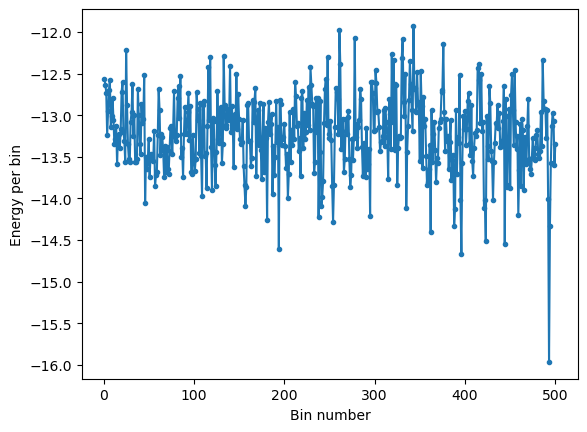

In [12]:
from py_alf.ana import read_scal, jack, error   # Low-level analysis routines

# Raw, un-rebinned bins of the energy (bin average / sign)
bins_c, sign, N_obs = read_scal(sim.sim_dir, 'Ener_scal', bare_bins=True)
ener_bins = bins_c[:, 0].real / sign.real

plt.figure()
plt.xlabel('Bin number')
plt.ylabel('Energy per bin')
plt.plot(range(1, len(ener_bins) + 1), ener_bins, '.-')


**6.** Quantify a safe `N_skip`.

We recompute the jackknife estimate of the energy while discarding an increasing number of leading bins, `N_skip`. While the discarded bins still include the equilibration transient, the estimate will drift; once enough bins have been discarded, it should fluctuate around a stable value:

<ErrorbarContainer object of 3 artists>

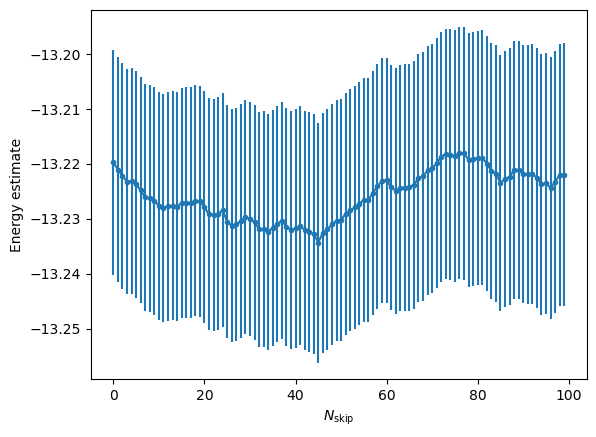

In [13]:
N_skip_max = 100                                 # Largest N_skip considered

means = np.empty(N_skip_max)
errs = np.empty(N_skip_max)
for N_skip in range(N_skip_max):
    J = jack(ener_bins, par=None, N_skip=N_skip, N_rebin=1)
    means[N_skip], errs[N_skip] = error(J)

plt.figure()
plt.xlabel(r'$N_\mathrm{skip}$')
plt.ylabel('Energy estimate')
plt.errorbar(range(N_skip_max), means, yerr=errs, fmt='.-')


---

If the earliest bins still reflect the initial, non-equilibrium configuration, the energy estimate drifts as `N_skip` increases past them; once `N_skip` exceeds the number of bins needed to equilibrate, the estimate settles into a stable value (within error bars). A safe choice of `N_skip` for the final analysis (e.g., via `sim.analysis(N_skip=...)`) is any value at or beyond this point.

## Exercises

1. Start the plot in Cell 12 from bin 1 instead of discarding anything, and compare it with the version using the `N_skip` you determined in Cell 14 to visually confirm the transient is excluded.
2. Repeat the analysis with a larger `beta` (lower temperature), which typically requires more sweeps to equilibrate, and check whether a larger `N_skip` is needed.
3. Repeat the analysis for a different observable (e.g., `Part_scal`) to see whether it equilibrates faster or slower than the energy.